In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [26]:
#-----------------------------Define the neural network models

class PINN(tf.keras.Model):
    def __init__(self, hidden_units=20, hidden_layers=3, activation='tanh'):
        super(PINN, self).__init__()
        self.hidden_layers = []
        for _ in range(hidden_layers):
            self.hidden_layers.append(tf.keras.layers.Dense(hidden_units, activation=activation))
        self.output_layer = tf.keras.layers.Dense(1, activation=None)
    
    def call(self, x):
        for layer in self.hidden_layers:
            x = layer(x)
        x = self.output_layer(x)
        return x


In [27]:
# Define the loss function for subdomain I1
@tf.function
def loss_I1(model1, model2, x1, f1, I1, overlap):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x1)
        u1 = model1(x1)
        u1_x = tape.gradient(u1, x1)
        u1_xx = tape.gradient(u1_x, x1)

    # Interior loss
    interior_loss = tf.reduce_mean(tf.square(u1[1, -1] - u1_xx[1, -1] + f1[1, -1]))

    # Boundary conditions
    bc1 = tf.square(model1(tf.constant([[I1[0]]], dtype=tf.float32)) - 0)

    # Transmission conditions
    Tc1 = tf.square(
        model1(tf.constant([[overlap[1]]], dtype=tf.float32)) -
        model2(tf.constant([[overlap[1]]], dtype=tf.float32))
    )

    loss = interior_loss + bc1 + Tc1
    return loss

# Define the loss function for subdomain I2
@tf.function
def loss_I2(model1, model2, x2, f2, I2, overlap):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x2)
        u2 = model2(x2)
        u2_x = tape.gradient(u2, x2)
        u2_xx = tape.gradient(u2_x, x2)

    # Interior loss
    interior_loss = tf.reduce_mean(tf.square(u2 - u2_xx - f2))

    # Boundary conditions
    bc2 = tf.square(model2(tf.constant([[I2[1]]], dtype=tf.float32)) - 0)

    # Transmission conditions
    Tc2 = tf.square(
        model2(tf.constant([[overlap[0]]], dtype=tf.float32)) -
        model1(tf.constant([[overlap[0]]], dtype=tf.float32))
    )

    loss = interior_loss + bc2 + Tc2
    return loss

In [28]:
# Instantiate models for each subdomain

model1 = PINN(hidden_units=20, hidden_layers=3, activation='tanh')
model2 = PINN(hidden_units=20, hidden_layers=3, activation='tanh')

# Save the initials weights
# Forcing
np.random.seed(42)
dummy_input = tf.constant(np.random.randn(1, 1), dtype=tf.float32)
model1(dummy_input)  # Initialise les poids du modèle 1
model2(dummy_input)  # Initialise les poids du modèle 2

# Sauvegarder les poids initiaux
initial_weights_model1 = model1.get_weights()
initial_weights_model2 = model2.get_weights()


In [29]:

Iter = []
deltas = [0.5, 0.3, 0.1, 1e-2, 1e-3] 

I = [-1, 1] ## Global domain
    
for h in deltas:
    print(f"For delta = {h}")

    # ----------------Definition of the subdomains---------------------
    I1 = [-1, h]
    I2 = [0, 1]
    overlap = [0, h]  # Overlapping domain

    # Number of training points in each subdomain
    N1 = 10
    N2 = 10

    #---------------------Generation of training points for each subdomain--------------------
    x1 = tf.Variable(np.linspace(I1[0], I1[1], N1).reshape(-1, 1), dtype=tf.float32)
    x2 = tf.Variable(np.linspace(I2[0], I2[1], N2).reshape(-1, 1), dtype=tf.float32)

    # ---------------------Generation of prediction data---------------
    x1_all = np.linspace(I1[0], I1[1], 200).reshape(-1, 1)
    x2_all = np.linspace(I2[0], I2[1], 200).reshape(-1, 1)

    # Function f1 and f2
    f1 = tf.zeros_like(x1)
    f2 = tf.zeros_like(x2)

    # Update the models with their initial value
    model1.set_weights(initial_weights_model1)
    model2.set_weights(initial_weights_model2)

    # ------------------------Definition of the optimizers------------------------
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=1e-3)
    optimizer2 = tf.keras.optimizers.Adam(learning_rate=1e-3)

    # --------------------Initialize the figure for animation--------------
    #fig, ax = plt.subplots(figsize=(8, 6))
    #ax.set_xlim(0, 500)  # Adjust based on expected number of epochs
    #ax.set_ylim(0, 1)  # Adjust based on expected loss values
    #ax.set_xlabel('Epochs')
    #ax.set_ylabel('Loss')
    #ax.set_title(f'Loss Dynamics for delta = {h}')
    #line1, = ax.plot([], [], label='Loss1 (Subdomain 1)', color='blue')
    #line2, = ax.plot([], [], label='Loss2 (Subdomain 2)', color='orange')
    #ax.legend()
    #ims = []  # For storing frames for animation

    # Training loop with while condition
    tol = 1e-5
    losses1 = []
    losses2 = []
    epoch = 0

    while True:
        # Train model1
        with tf.GradientTape() as tape1:
            loss1 = loss_I1(model1, model2, x1, f1, I1, overlap)
        grads1 = tape1.gradient(loss1, model1.trainable_variables)
        optimizer1.apply_gradients(zip(grads1, model1.trainable_variables))

        # Train model2
        with tf.GradientTape() as tape2:
            loss2 = loss_I2(model1, model2, x2, f2, I2, overlap)
        grads2 = tape2.gradient(loss2, model2.trainable_variables)
        optimizer2.apply_gradients(zip(grads2, model2.trainable_variables))

        losses1.append(loss1.numpy().item())
        losses2.append(loss2.numpy().item())

        # Update plot for animation
        #line1.set_data(range(len(losses1)), losses1)
        #line2.set_data(range(len(losses2)), losses2)
        #ims.append([line1, line2])

        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss1: {loss1.numpy()}, Loss2: {loss2.numpy()}")

        epoch += 1

        if epoch == 1:
            u1_first_pred = model1(tf.constant(x1_all, dtype=tf.float32)).numpy()
            u2_first_pred = model2(tf.constant(x2_all, dtype=tf.float32)).numpy()

        if loss1.numpy() + loss2.numpy() < tol:
            Iter.append(epoch)
            print(f"Last Epoch {epoch}, Loss1: {loss1.numpy()}, Loss2: {loss2.numpy()}")
            print("\n")
            break

    # Create and save animation
    #ani = animation.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
    #ani.save(f"loss_dynamics_delta_{h}.gif", writer=animation.PillowWriter(fps=10))
    #plt.close(fig)

print("Animation saved for all deltas.")


For delta = 0.5
Epoch 0, Loss1: [[0.17262778]], Loss2: [[0.5240527]]
Epoch 50, Loss1: [[0.00059573]], Loss2: [[0.00029792]]
Epoch 100, Loss1: [[9.383101e-05]], Loss2: [[0.0001529]]
Epoch 150, Loss1: [[9.7766815e-06]], Loss2: [[8.981172e-05]]
Epoch 200, Loss1: [[5.2557186e-07]], Loss2: [[4.8623624e-05]]
Epoch 250, Loss1: [[1.1400094e-08]], Loss2: [[2.679143e-05]]
Epoch 300, Loss1: [[3.7463855e-11]], Loss2: [[1.6219909e-05]]
Epoch 350, Loss1: [[2.5546995e-12]], Loss2: [[1.0834444e-05]]
Last Epoch 363, Loss1: [[2.630143e-12]], Loss2: [[9.940563e-06]]


For delta = 0.3
Epoch 0, Loss1: [[0.16825965]], Loss2: [[0.5240527]]
Epoch 50, Loss1: [[0.00065595]], Loss2: [[0.00028428]]
Epoch 100, Loss1: [[0.00013956]], Loss2: [[0.00014079]]
Epoch 150, Loss1: [[2.039071e-05]], Loss2: [[8.4098494e-05]]
Epoch 200, Loss1: [[1.6936343e-06]], Loss2: [[4.8817208e-05]]
Epoch 250, Loss1: [[6.1569544e-08]], Loss2: [[2.8562577e-05]]
Epoch 300, Loss1: [[1.3433522e-09]], Loss2: [[1.7507293e-05]]
Epoch 350, Loss1:

In [36]:
Iter 

[363, 368, 394, 431, 447]

In [37]:
h_1 = [1/h for h in deltas]

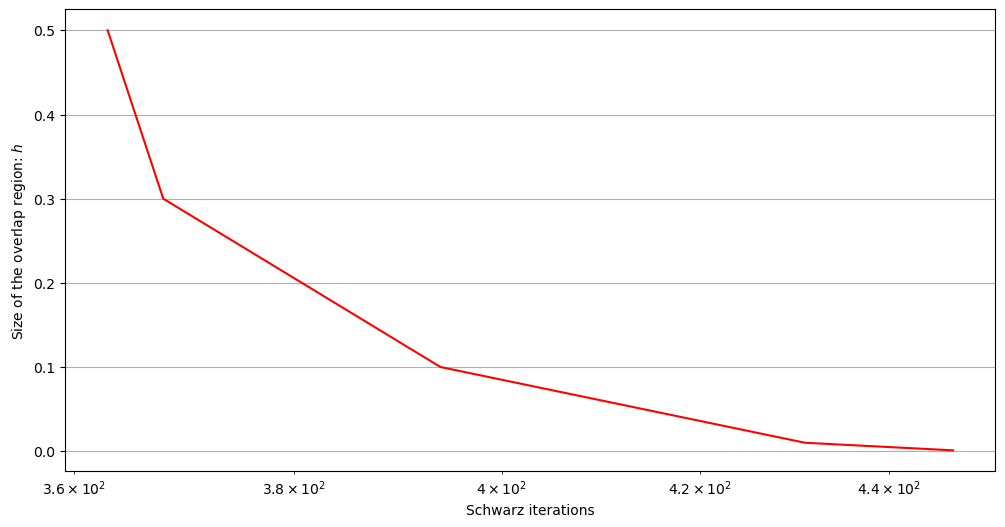

In [48]:
plt.figure( figsize=(12, 6))
plt.plot(Iter, deltas, "red")
plt.xlabel("Schwarz iterations")
plt.ylabel("Size of the overlap region: $h$")
plt.xscale("log")
#plt.yscale("log")
plt.grid(True)

> #### *The number of Schwarz iterations is inversely proportional to the size of the overlap region.*

# Predictions

> ## --------------Preditions at first iteration---------------


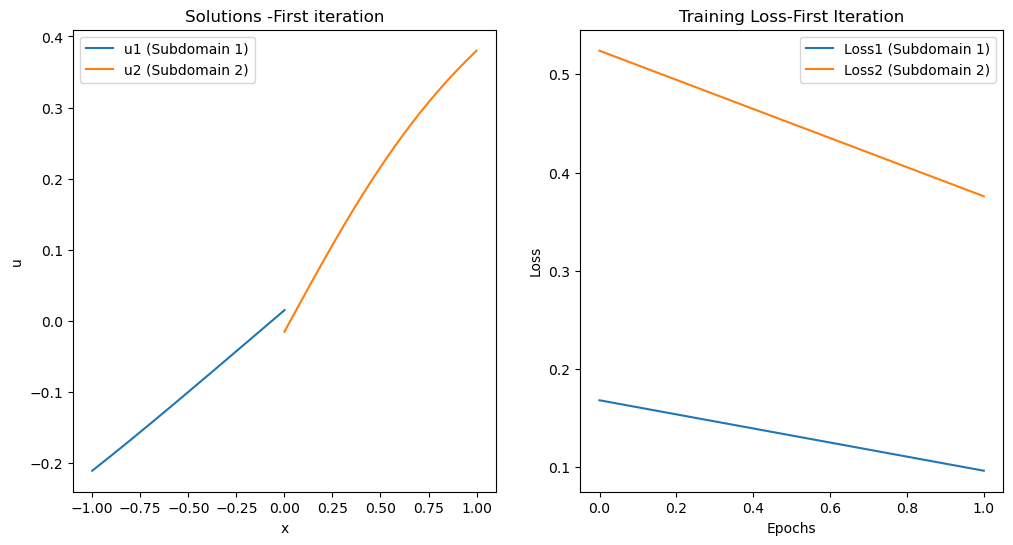

In [49]:
# For video recording
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ims = []

im1, = ax1.plot(x1_all, u1_first_pred, label='u1 (Subdomain 1)')
im2, = ax1.plot(x2_all, u2_first_pred, label='u2 (Subdomain 2)')
ax1.set_xlabel('x')
ax1.set_ylabel('u')
ax1.set_title('Solutions -First iteration')
ax1.legend()

im3, = ax2.plot(losses1[:2], label='Loss1 (Subdomain 1)')
im4, = ax2.plot(losses2[:2], label='Loss2 (Subdomain 2)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_title('Training Loss-First Iteration')
ax2.legend()

plt.show()

> ## --------------Preditions at last iteration---------------

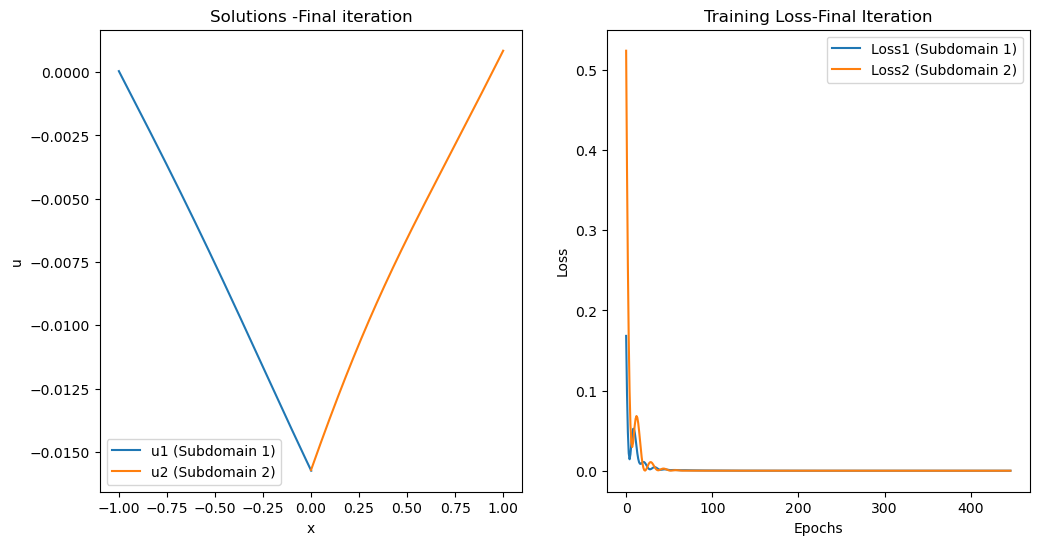

In [50]:
## Last iteration
u1_pred = model1(tf.constant(x1_all, dtype=tf.float32)).numpy()
u2_pred = model2(tf.constant(x2_all, dtype=tf.float32)).numpy()

# For video recording
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ims = []

im1, = ax1.plot(x1_all, u1_pred, label='u1 (Subdomain 1)')
im2, = ax1.plot(x2_all, u2_pred, label='u2 (Subdomain 2)')
ax1.set_xlabel('x')
ax1.set_ylabel('u')
ax1.set_title('Solutions -Final iteration')
ax1.legend()

im3, = ax2.plot(losses1, label='Loss1 (Subdomain 1)')
im4, = ax2.plot(losses2, label='Loss2 (Subdomain 2)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_title('Training Loss-Final Iteration')
ax2.legend()

#ims.append([im1, im2, im3, im4])

#ani = animation.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
#ani.save("training_animation.gif", writer=animation.PillowWriter(fps=10))

plt.show()


> ## --------------Preditions on the global domain---------------

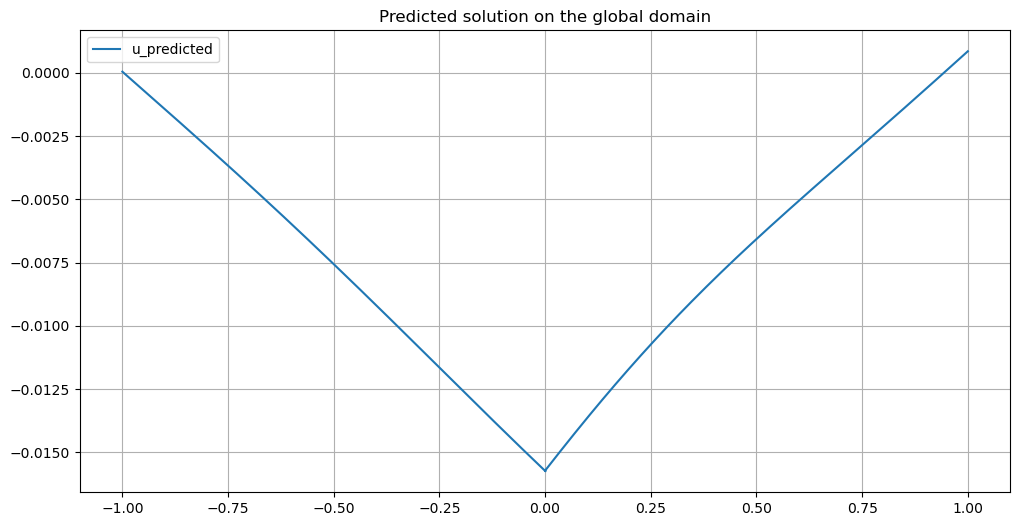

In [53]:
combined_pred = np.concatenate((u1_pred, u2_pred), axis=0)
x_full = np.concatenate((x1_all, x2_all), axis=0)


plt.figure(figsize=(12, 6))
plt.plot(x_full, combined_pred, label="u_predicted")
plt.title("Predicted solution on the global domain")
plt.grid(True)
plt.legend()


In [54]:
model1.summary()

Model: "pinn_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (1, 20)                │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (1, 20)                │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (1, 20)                │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (1, 1)                 │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 901 (3.52 KB)

 Trainable params: 901 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model2.summary()

Model: "pinn_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (1, 20)                │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (1, 20)                │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (1, 20)                │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (1, 1)                 │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 901 (3.52 KB)

 Trainable params: 901 (3.52 KB)

 Non-trainable params: 0 (0.00 B)